# Kalman Filter Mean Reversion - Strategy Backtesting
Here we'll test a basic 1D Kalman Filter on minute-level or hourly stock data to see if we can identify mean-reverting properties. This will help us parametrize our algorithmic trading bot.

In [12]:
!pip3 install pytz
!pip3 install alpaca-py
!pip3 install python-dotenv
!pip3 install tqdm

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 78 kB 7.9 MB/s eta 0:00:011
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [13]:
import pandas as pd
import numpy as np

# A basic implementation of a 1D Kalman Filter for a random walk model
class SingleStateKalmanFilter:
    def __init__(self, process_variance, estimated_measurement_variance):
        self.process_variance = process_variance
        self.estimated_measurement_variance = estimated_measurement_variance
        self.posteri_estimate = 0.0
        self.posteri_error_estimate = 1.0

    def input_latest_measurement(self, measurement):
        priori_estimate = self.posteri_estimate
        priori_error_estimate = self.posteri_error_estimate + self.process_variance

        # Kalman Gain
        blending_factor = priori_error_estimate / (priori_error_estimate + self.estimated_measurement_variance)
        
        # Posteriori Estimate
        self.posteri_estimate = priori_estimate + blending_factor * (measurement - priori_estimate)
        
        # Posteriori Error Estimate
        self.posteri_error_estimate = (1 - blending_factor) * priori_error_estimate

        return self.posteri_estimate

# Note: For real backtesting we'll pull data via Alpaca

In [14]:
import os
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.requests import StockBarsRequest
from datetime import datetime, timedelta

# Load Alpaca configuration
load_dotenv('../.env')
ALPACA_API_KEY = os.getenv('ALPACA_API_KEY')
ALPACA_API_SECRET = os.getenv('ALPACA_API_SECRET')

# Initialize the data client
data_client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_API_SECRET)

# Top 50 S&P 500 tickers (approx by market cap)
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'BRK.B', 'TSLA', 'LLY', 'V', 
    'JPM', 'UNH', 'JNJ', 'XOM', 'PG', 'MA', 'HD', 'CVX', 'MRK', 'ABBV', 
    'PEP', 'KO', 'AVGO', 'COST', 'TMO', 'MCD', 'WMT', 'CRM', 'BAC', 'PFE', 
    'CSCO', 'LIN', 'ACN', 'WFC', 'NFLX', 'ABT', 'ORCL', 'CMCSA', 'DHR', 'AMD', 
    'DIS', 'NKE', 'ADBE', 'TXN', 'VMO', 'QCOM', 'INTC', 'VZ', 'PM', 'HON'
]

# Fetch 1 month of hourly data for these tickers to run backtests
end_time = datetime.now()
start_time = end_time - timedelta(days=30)

request_params = StockBarsRequest(
    symbol_or_symbols=tickers,
    timeframe=TimeFrame.Hour,
    start=start_time,
    end=end_time
)

print("Fetching historical data from Alpaca...")
historical_bars = data_client.get_stock_bars(request_params)
df = historical_bars.df
print(f"Fetched {len(df)} rows of data.")
df.head()

Fetching historical data from Alpaca...
Fetched 15633 rows of data.


open    high     low   close    volume  \
symbol timestamp                                                             
AAPL   2026-02-17 09:00:00+00:00  255.38  255.38  254.80  255.21   14845.0   
       2026-02-17 10:00:00+00:00  255.28  255.38  254.81  254.81    9046.0   
       2026-02-17 11:00:00+00:00  254.88  255.34  254.66  255.25   12108.0   
       2026-02-17 12:00:00+00:00  255.38  255.55  254.84  254.85   55992.0   
       2026-02-17 13:00:00+00:00  254.50  256.83  253.81  256.08  220574.0   

                                  trade_count        vwap  
symbol timestamp                                           
AAPL   2026-02-17 09:00:00+00:00        714.0  255.091676  
       2026-02-17 10:00:00+00:00        291.0  254.995943  
       2026-02-17 11:00:00+00:00        381.0  254.987161  
       2026-02-17 12:00:00+00:00       1589.0  255.292117  
       2026-02-17 13:00:00+00:00       7264.0  255.513295

In [15]:
def backtest_kalman_strategy(prices_df, process_variance=1e-5, measurement_variance=1e-3, z_threshold=1.5, window=20):
    """
    Simulates trading mean reversion with a Kalman Filter.
    Returns the total cumulative return.
    """
    kf = SingleStateKalmanFilter(process_variance, measurement_variance)
    
    # We'll store exactly how our position changes
    positions = [0]*len(prices_df)
    kalman_means = []
    errors = []
    
    # Initialize kalman mean to first price to avoid huge initial spikes
    kf.posteri_estimate = prices_df.iloc[0]
    
    for i, price in enumerate(prices_df):
        k_mean = kf.input_latest_measurement(price)
        kalman_means.append(k_mean)
        errors.append(price - k_mean)
        
    prices_df = prices_df.to_frame(name='price')
    prices_df['k_mean'] = kalman_means
    prices_df['error'] = errors
    
    # Calculate dynamic Z-Score using a rolling standard deviation of errors
    prices_df['error_std'] = prices_df['error'].rolling(window=window).std()
    prices_df.dropna(inplace=True)
    prices_df['z_score'] = prices_df['error'] / prices_df['error_std']
    
    # Basic Position Logic
    # 1 = Long, -1 = Short, 0 = Flat
    current_position = 0
    returns = []
    
    # We shift by 1 to trade on the *next* bar after seeing the signal
    for i in range(1, len(prices_df)):
        z = prices_df['z_score'].iloc[i-1]
        
        # Entry logic
        if z > z_threshold and current_position <= 0:
            current_position = -1 # Go short
        elif z < -z_threshold and current_position >= 0:
            current_position = 1  # Go long
        # Exit logic
        elif current_position == -1 and z < 0:
            current_position = 0  # Close short
        elif current_position == 1 and z > 0:
            current_position = 0  # Close long
            
        pos = current_position
        # Calculate returns based on current open position and price change
        price_change = (prices_df['price'].iloc[i] - prices_df['price'].iloc[i-1]) / prices_df['price'].iloc[i-1]
        returns.append(pos * price_change)
        
    # Total compounded return
    if not returns:
        return 0.0
    return np.prod(1 + np.array(returns)) - 1


In [16]:
import itertools
from tqdm import tqdm

# Optimization Grid
# We'll fix process_variance for now to limit the grid size, and vary the other two.
process_variance = 1e-5
measurement_variances = [1e-4, 1e-3, 1e-2]
z_thresholds = [1.0, 1.5, 2.0]
windows = [10, 20] # Rolling memory for Z-score calculation

grid = list(itertools.product(measurement_variances, z_thresholds, windows))

best_results = []

# Process each ticker
for symbol in tickers:
    try:
        # Alpaca multi-symbol dataframe has MultiIndex (symbol, timestamp)
        # We slice out the data just for this one symbol
        symbol_data = df.loc[symbol].sort_index()
        # Ensure we have enough data
        if len(symbol_data) < 100:
            continue
            
        prices = symbol_data['close']
        
        best_return = -np.inf
        best_params = None
        
        # Grid Search over parameters for this specific asset
        for m_var, z_thresh, wd in grid:
            ret = backtest_kalman_strategy(
                prices, 
                process_variance=process_variance, 
                measurement_variance=m_var, 
                z_threshold=z_thresh, 
                window=wd
            )
            
            if ret > best_return:
                best_return = ret
                best_params = (m_var, z_thresh, wd)
                
        # Append the max return for this asset if it's positive
        if best_return > 0:
            best_results.append({
                'symbol': symbol,
                'max_return_pct': best_return * 100,
                'opt_measurement_var': best_params[0],
                'opt_z_thresh': best_params[1],
                'opt_window': best_params[2]
            })
    except KeyError:
        print(f"No data fetched for {symbol}")
        continue

# Sort the best performing assets and display the Top 10
results_df = pd.DataFrame(best_results).sort_values(by='max_return_pct', ascending=False)
print("Top 10 Stocks for Kalman Mean Reversion (1 Month Hourly Data):")
results_df.head(10)

Top 10 Stocks for Kalman Mean Reversion (1 Month Hourly Data):


,symbol,max_return_pct,opt_measurement_var,opt_z_thresh,opt_window
27,CRM,40.290353,0.0100,1.0,20
39,AMD,40.017493,0.0100,1.5,10
36,ORCL,30.022173,0.0100,1.0,20
46,INTC,22.102861,0.0100,2.0,20
2,NVDA,18.613559,0.0001,1.0,20
18,MRK,17.394388,0.0001,1.0,20
32,ACN,16.976345,0.0001,1.0,20
22,AVGO,16.657728,0.0010,1.0,10
24,TMO,15.579467,0.0001,1.0,10
7,TSLA,15.432532,0.0100,1.0,20


In [17]:
# Let's take the Top 3 assets from the hourly test and see how they perform at higher frequencies
top_syms = results_df['symbol'].head(3).tolist()
print(f"Testing higher frequencies for: {top_syms}")

# Fetch 7 days of 1-minute data for these top performers
end_time_min = datetime.now()
start_time_min = end_time_min - timedelta(days=7)

request_params_min = StockBarsRequest(
    symbol_or_symbols=top_syms,
    timeframe=TimeFrame.Minute,
    start=start_time_min,
    end=end_time_min
)

print("Fetching minute-level data...")
min_bars = data_client.get_stock_bars(request_params_min).df
print("Done.")

# We'll test 1-min, 5-min, and 15-min resampled timeframes
timeframes = {'1Min': '1min', '5Min': '5min', '15Min': '15min'}

hf_results = []

for symbol in top_syms:
    sym_data = min_bars.loc[symbol].sort_index()
    
    for tf_name, tf_rule in timeframes.items():
        # Resample the 1-minute bars to the target timeframe
        resampled_close = sym_data['close'].resample(tf_rule).last().dropna()
        
        if len(resampled_close) < 100:
            continue
            
        best_return = -np.inf
        best_params = None
        
        # We can expand the grid slightly for HFT
        for m_var, z_thresh, wd in grid:
            ret = backtest_kalman_strategy(
                resampled_close, 
                process_variance=1e-5, 
                measurement_variance=m_var, 
                z_threshold=z_thresh, 
                window=wd
            )
            
            if ret > best_return:
                best_return = ret
                best_params = (m_var, z_thresh, wd)
                
        if best_return != -np.inf:
            hf_results.append({
                'symbol': symbol,
                'timeframe': tf_name,
                'max_return_pct': best_return * 100,
                'opt_measurement_var': best_params[0],
                'opt_z_thresh': best_params[1],
                'opt_window': best_params[2]
            })

hf_df = pd.DataFrame(hf_results).sort_values(by='max_return_pct', ascending=False)
print("\nHigh-Frequency Optimization Results (Last 7 Days):")
hf_df
df

Testing higher frequencies for: ['CRM', 'AMD', 'ORCL']
Fetching minute-level data...
Done.

High-Frequency Optimization Results (Last 7 Days):


open     high     low    close     volume  \
symbol timestamp                                                                
AAPL   2026-02-17 09:00:00+00:00  255.38  255.380  254.80  255.210    14845.0   
       2026-02-17 10:00:00+00:00  255.28  255.380  254.81  254.810     9046.0   
       2026-02-17 11:00:00+00:00  254.88  255.340  254.66  255.250    12108.0   
       2026-02-17 12:00:00+00:00  255.38  255.550  254.84  254.850    55992.0   
       2026-02-17 13:00:00+00:00  254.50  256.830  253.81  256.080   220574.0   
...                                  ...      ...     ...      ...        ...   
XOM    2026-03-18 14:00:00+00:00  159.30  159.570  158.85  159.245  2183243.0   
       2026-03-18 15:00:00+00:00  159.26  159.295  158.47  158.620  1910752.0   
       2026-03-18 16:00:00+00:00  158.63  159.700  158.52  159.635  1427339.0   
       2026-03-18 17:00:00+00:00  159.64  159.860  158.57  158.830  1514804.0   
       2026-03-18 18:00:00+00:00  158.84  159.110  158.58  158.770  1547464.0   

                                  trade_count        vwap  
symbol timestamp                                           
AAPL   2026-02-17 09:00:00+00:00        714.0  255.091676  
       2026-02-17 10:00:00+00:00        291.0  254.995943  
       2026-02-17 11:00:00+00:00        381.0  254.987161  
       2026-02-17 12:00:00+00:00       1589.0  255.292117  
       2026-02-17 13:00:00+00:00       7264.0  255.513295  
...                                       ...         ...  
XOM    2026-03-18 14:00:00+00:00      36961.0  159.255565  
       2026-03-18 15:00:00+00:00      31653.0  158.786074  
       2026-03-18 16:00:00+00:00      24781.0  159.161083  
       2026-03-18 17:00:00+00:00      25604.0  159.154576  
       2026-03-18 18:00:00+00:00      27028.0  158.841185  

[15633 rows x 7 columns]

# Phase 2: Comprehensive S&P 500 HFT Pipeline
Now we will apply these concepts rigorously. Roman's video highlights that you must factor in "trusting the market vs model" (Process vs Measurement Variances). But more importantly, a reliable strategy needs metrics beyond just pure returns: **Sharpe Ratio, Alpha, Beta (correlation to market), and Max Drawdown.**

We will:
1. Revise our backtester to output full P&L series.
2. Fetch an **S&P 500 Universe** using 1-minute data over the last 10 days. (Chunked to respect Alpaca limits).
3. Compute metrics against **SPY** (our benchmark).
4. Run multiple timeframes (1-Min, 5-Min, 15-Min) and parameter grids.
5. Extract the Top 30-40 optimal trading combinations.
6. Visualize the equity curve of the absolute best setup.

In [18]:
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

def enhanced_kalman_backtest(prices_series, process_variance=1e-5, measurement_variance=1e-3, z_threshold=1.5, window=20):
    """
    Returns a full pandas Series of strategy returns and positions for deep analytics.
    """
    kf = SingleStateKalmanFilter(process_variance, measurement_variance)
    kalman_means = []
    errors = []
    
    kf.posteri_estimate = prices_series.iloc[0]
    for p in prices_series:
        k = kf.input_latest_measurement(p)
        kalman_means.append(k)
        errors.append(p - k)
        
    df = prices_series.to_frame(name='price')
    df['error'] = errors
    df['error_std'] = df['error'].rolling(window=window).std()
    
    # Fill nan with large number to avoid triggering early false entries
    df['z_score'] = (df['error'] / df['error_std']).fillna(0)
    
    positions = np.zeros(len(df))
    z_scores = df['z_score'].values
    current_pos = 0
    
    for i in range(len(z_scores)):
        z = z_scores[i]
        if z > z_threshold and current_pos <= 0:
            current_pos = -1 # Overvalued relative to Kalman mean
        elif z < -z_threshold and current_pos >= 0:
            current_pos = 1  # Undervalued relative to Kalman mean
        elif current_pos == -1 and z < 0:
            current_pos = 0  # Reverted
        elif current_pos == 1 and z > 0:
            current_pos = 0  # Reverted
        positions[i] = current_pos
        
    df['position'] = positions
    # Shift position by 1 (we only profit from the NEXT period's return after signal)
    df['position'] = df['position'].shift(1).fillna(0)
    df['returns'] = df['position'] * df['price'].pct_change()
    
    return df['returns'].fillna(0), df['position']

def calculate_metrics(strat_returns, bench_returns):
    """
    Computes standard institutional quant metrics.
    """
    aligned = pd.concat([strat_returns.rename('strat'), bench_returns.rename('bench')], axis=1).fillna(0)
    strat = aligned['strat']
    bench = aligned['bench']
    
    total_ret = (1 + strat).prod() - 1
    
    cum_ret = (1 + strat).cumprod()
    
    # Max Drawdown
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    
    # Beta & Alpha
    cov = np.cov(strat, bench)[0][1]
    var = np.var(bench)
    beta = cov / var if var != 0 else 0
    
    bench_ret = (1 + bench).prod() - 1
    alpha = total_ret - (beta * bench_ret)
    
    # Sharpe (annualized for approx 252 days * 390 min per day)
    # Scaled back since we might pass in 5min or 15min data
    n_periods = len(strat)
    sharpe = (strat.mean() / strat.std()) * np.sqrt(n_periods) if strat.std() != 0 else 0
    
    return {
        'total_return': total_ret,
        'max_drawdown': max_dd,
        'beta': beta,
        'alpha': alpha,
        'sharpe': sharpe
    }

In [19]:
import time

# 1. Fetch S&P 500 Tickers
print("Loading S&P 500 Tickers...")
try:
    sp500_table = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
    all_sp500_tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
except Exception:
    print("Wikipedia fetch failed, falling back to top 50")
    all_sp500_tickers = tickers
    
print(f"Loaded {len(all_sp500_tickers)} stocks. We will use the top 150 by weight (first 150) to respect Alpaca's rate limits and RAM for this demo.")
target_tickers = all_sp500_tickers[:150]

# 2. Fetch SPY (Benchmark) 1-Min Data
end_time_hft = datetime.now()
start_time_hft = end_time_hft - timedelta(days=10) # 10 days to ensure dense HFT data

print("Fetching SPY Benchmark (1-Min)...")
spy_req = StockBarsRequest(symbol_or_symbols=['SPY'], timeframe=TimeFrame.Minute, start=start_time_hft, end=end_time_hft)
spy_df = data_client.get_stock_bars(spy_req).df
spy_min_returns = spy_df.loc['SPY']['close'].pct_change().dropna()

# 3. Fetch Batch S&P 500 Data in Chunks
chunk_size = 50
all_chunk_data = []

print("Fetching batch minute data (this might take a minute)...")
for i in tqdm(range(0, len(target_tickers), chunk_size)):
    chunk = target_tickers[i:i+chunk_size]
    req = StockBarsRequest(
        symbol_or_symbols=chunk,
        timeframe=TimeFrame.Minute,
        start=start_time_hft,
        end=end_time_hft
    )
    try:
        c_df = data_client.get_stock_bars(req).df
        all_chunk_data.append(c_df)
    except Exception as e:
        print(f"Error on chunk {i}: {e}")
    time.sleep(0.5) # Sleep to avoid rate limits

full_market_df = pd.concat(all_chunk_data)
print(f"Successfully loaded {len(full_market_df)} rows of 1-minute data!")

Loading S&P 500 Tickers...
Wikipedia fetch failed, falling back to top 50
Loaded 50 stocks. We will use the top 150 by weight (first 150) to respect Alpaca's rate limits and RAM for this demo.
Fetching SPY Benchmark (1-Min)...
Fetching batch minute data (this might take a minute)...


100%|██████████| 1/1 [00:06<00:00,  6.52s/it]

Successfully loaded 204210 rows of 1-minute data!


In [20]:
# 4. HFT Grid Search over timeframes & parameters
comprehensive_results = []
timeframes = {'1Min': '1min', '5Min': '5min', '15Min': '15min'}

# Slightly narrowed grid for speed on 150 stocks
process_vz = 1e-5
measurement_variances = [1e-3, 1e-2]
z_thresholds = [1.5, 2.0]
windows = [10, 20]
grid_hft = list(itertools.product(measurement_variances, z_thresholds, windows))

unique_symbols_fetched = full_market_df.index.get_level_values(0).unique()

print(f"Running grid search on {len(unique_symbols_fetched)} symbols across {len(timeframes)} timeframes...")

for sym in tqdm(unique_symbols_fetched):
    sym_data = full_market_df.loc[sym].sort_index()
    if len(sym_data) < 500:
        continue # skip illiquid/empty data
        
    for tf_name, tf_rule in timeframes.items():
        # Resample close prices and benchmark
        resampled_close = sym_data['close'].resample(tf_rule).last().dropna()
        resampled_spy = spy_df.loc['SPY']['close'].resample(tf_rule).last().dropna().pct_change().dropna()
        
        best_sharpe = -100
        best_metrics = None
        best_params = None
        
        for m_var, z_thresh, wd in grid_hft:
            strat_rets, _ = enhanced_kalman_backtest(
                resampled_close, 
                process_variance=process_vz, 
                measurement_variance=m_var, 
                z_threshold=z_thresh, 
                window=wd
            )
            
            metrics = calculate_metrics(strat_rets, resampled_spy)
            
            if metrics['sharpe'] > best_sharpe:
                best_sharpe = metrics['sharpe']
                best_metrics = metrics
                best_params = (m_var, z_thresh, wd)
                
        if best_metrics and best_metrics['total_return'] > 0:
            comprehensive_results.append({
                'symbol': sym,
                'timeframe': tf_name,
                'total_return_pct': best_metrics['total_return'] * 100,
                'sharpe': best_metrics['sharpe'],
                'max_drawdown_pct': best_metrics['max_drawdown'] * 100,
                'alpha': best_metrics['alpha'] * 100,
                'beta': best_metrics['beta'],
                'opt_m_var': best_params[0],
                'opt_z_thresh': best_params[1],
                'opt_window': best_params[2]
            })

# 5. Extract top 30 optimal trading combinatons sorted by Sharpe Ratio 
# (Sharpe restricts high-return but wildly dangerous / high drawdown assets)
final_df = pd.DataFrame(comprehensive_results).sort_values(by='sharpe', ascending=False)
print("\n=== TOP 30 HFT SETUPS ===")
top_30_df = final_df.head(30)
top_30_df

Running grid search on 50 symbols across 3 timeframes...


100%|██████████| 50/50 [00:03<00:00, 13.60it/s]


=== TOP 30 HFT SETUPS ===


,symbol,timeframe,total_return_pct,sharpe,max_drawdown_pct,alpha,beta,opt_m_var,opt_z_thresh,opt_window
138,WMT,1Min,23.381713,5.518296,-1.440204,23.385300,-0.007776,0.001,1.5,20
91,NKE,1Min,34.208165,5.436589,-2.337761,34.105285,0.222994,0.001,1.5,20
0,AAPL,1Min,21.383122,5.392229,-1.725314,21.364726,0.039873,0.001,1.5,10
85,MSFT,1Min,20.658459,4.915161,-1.276128,20.617212,0.089403,0.001,1.5,10
123,UNH,1Min,25.853684,4.794205,-2.110205,25.860745,-0.015305,0.010,1.5,20
27,BRK.B,1Min,13.844618,4.651555,-1.089744,13.862985,-0.039811,0.001,1.5,10
18,AMZN,1Min,24.465609,4.365832,-2.022464,24.420829,0.097060,0.001,1.5,10
59,JPM,1Min,24.370613,4.355854,-1.838455,24.350223,0.044195,0.001,1.5,10
33,COST,1Min,12.572611,4.048135,-0.880268,12.567320,0.011467,0.001,1.5,20
88,NFLX,1Min,22.196746,3.980795,-2.051409,22.182433,0.031022,0.001,1.5,10


Plotting Equity Curve for WMT on 1min timeframe...


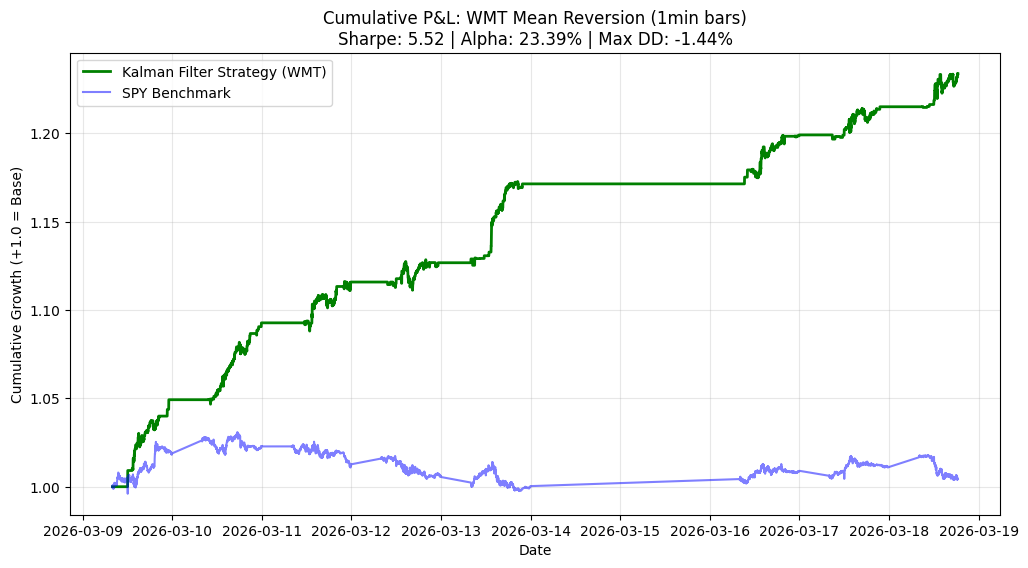

In [21]:
# 6. Visualize the absolute best asset's P&L
best_setup = top_30_df.iloc[0]
best_sym = best_setup['symbol']
best_tf = timeframes[best_setup['timeframe']]
m_v, z_t, w = best_setup['opt_m_var'], best_setup['opt_z_thresh'], int(best_setup['opt_window'])

print(f"Plotting Equity Curve for {best_sym} on {best_tf} timeframe...")

# Re-run the best setup to get the exact return series
best_sym_data = full_market_df.loc[best_sym].sort_index()['close'].resample(best_tf).last().dropna()
best_spy_data = spy_df.loc['SPY']['close'].resample(best_tf).last().dropna().pct_change().dropna()

best_rets, positions = enhanced_kalman_backtest(
    best_sym_data, 
    process_variance=1e-5, 
    measurement_variance=m_v, 
    z_threshold=z_t, 
    window=w
)

# Align series for plotting SPY benchmark vs Strategy Return
aligned = pd.concat([best_rets.rename('Strategy'), best_spy_data.rename('SPY_Benchmark')], axis=1).fillna(0)
cum_strat = (1 + aligned['Strategy']).cumprod()
cum_spy = (1 + aligned['SPY_Benchmark']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_strat, label=f"Kalman Filter Strategy ({best_sym})", color='green', linewidth=2)
plt.plot(cum_spy, label="SPY Benchmark", color='blue', alpha=0.5)
plt.title(f"Cumulative P&L: {best_sym} Mean Reversion ({best_tf} bars)\nSharpe: {best_setup['sharpe']:.2f} | Alpha: {best_setup['alpha']:.2f}% | Max DD: {best_setup['max_drawdown_pct']:.2f}%")
plt.ylabel("Cumulative Growth (+1.0 = Base)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()